## Ноутбук с разведочным анализом данных и созданием новых признаков

1. Импорт бибилиотек и конфигурация проекта

In [2]:
# Создадим словарь конфигураций.

CONFIG = {
    # Константы
    "DEV_MODE": False,
    "DEV_SAMPLE_SIZE": 100000,
    "RANDOM_STATE": 42,
    # Целевая переменная 
    "TARGET": "Цена",
    # Колонки с категориальными признаками
    "CAT_COLS": ['Название машины', 'Тип двигателя', 'Коробка передач', 'Привод', 'Руль', 'Цвет', 'Комплектация', 'Тип кузова', 'Марка', 'Город', 'Регион', 'Макро-регион']
}

In [3]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pyarrow

In [4]:
df = pd.read_parquet("../data/processed/train_cleaned.parquet")

2. Проверка на адекватность

In [5]:
df.head(5)

,Название машины,Год,Объем двигателя,Тип двигателя,Мощность,Коробка передач,Привод,Пробег,Руль,Поколение,...,Цвет,Комплектация,Тип кузова,Марка,Город,Регион,Макро-регион,Владельцы,Есть особые отметки,Цена
456584,Toyota Corolla Spacio,2003.0,1.5,бензин,109.0,АКПП,передний,228000.0,правый,2.0,...,серый,1.5 X G edition,минивэн,toyota,Якутск,Республика Саха,ДФО,4.0,0.0,650000.0
476657,Toyota Corolla,2007.0,1.6,бензин,124.0,РКПП,передний,237000.0,левый,10.0,...,голубой,1.6 MultiMode Престиж,седан,toyota,Рославль,Смоленская область,ЦФО,2.0,0.0,800000.0
436621,Subaru Legacy,1994.0,2.2,бензин,136.0,АКПП,4WD,200000.0,левый,1.0,...,бордовый,2.2 AT Classic Super-Station,универсал,subaru,Москва,Москва,Москва,4.0,1.0,100000.0
479257,Toyota Camry,2007.0,3.5,бензин,277.0,АКПП,передний,319801.0,левый,7.0,...,черный,3.5 AT Luxe,седан,toyota,Иркутск,Иркутская область,СФО,4.0,0.0,790000.0
340053,Mitsubishi Colt,1996.0,1.3,бензин,75.0,АКПП,передний,246000.0,левый,5.0,...,зеленый,1.3 AT GLX,хэтчбек 3 дв.,mitsubishi,Солнечногорск,Московская область,ЦФО,3.0,0.0,250000.0


In [6]:
df.shape

(464926, 21)

In [7]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(cat_cols)

['Название машины', 'Тип двигателя', 'Коробка передач', 'Привод', 'Руль', 'Цвет', 'Комплектация', 'Тип кузова', 'Марка', 'Город', 'Регион', 'Макро-регион']


C:\Users\Степан\AppData\Local\Temp\ipykernel_7392\1233978785.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


3. Анализ целевой переменной

<Axes: xlabel='Цена', ylabel='Count'>

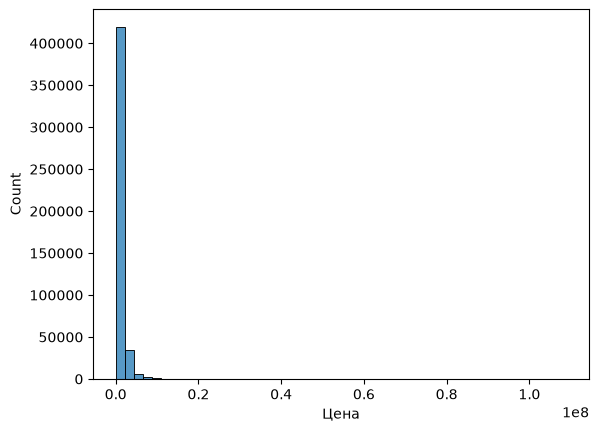

In [8]:
sns.histplot(data=df, x=CONFIG["TARGET"], bins=50)

Заметим, что распределение целевой переменной обладает сильной правосторонней асимметрией (длинным правым хвостом). В дальнейшем планируется прологарифмировать таргет, чтобы приблизить его распределение к нормальному (симметричному)

4. Одномерный анализ признаков

4.1 Числовые признаки

In [9]:
print(num_cols)

['Год', 'Объем двигателя', 'Мощность', 'Пробег', 'Поколение', 'Рестайлинг', 'Владельцы', 'Есть особые отметки', 'Цена']


Распределение для столбца 'Год'


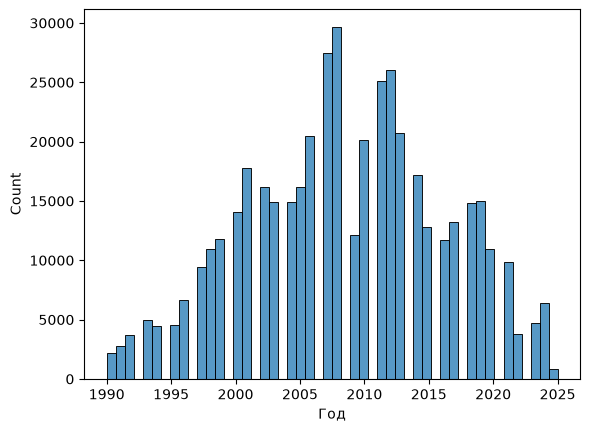

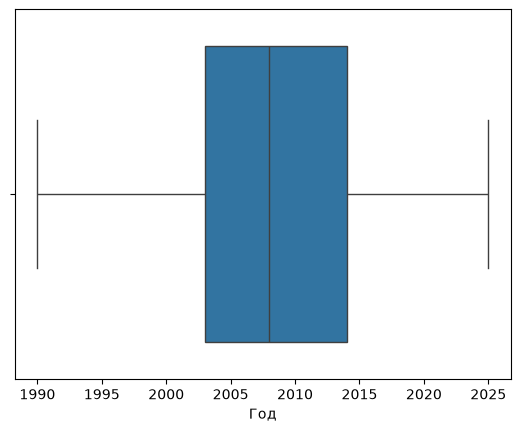

Распределение для столбца 'Объем двигателя'


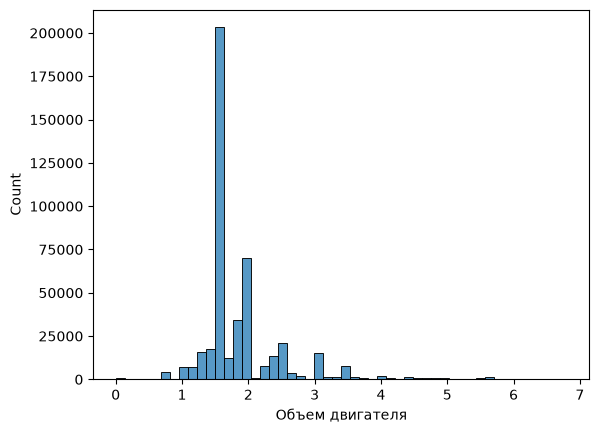

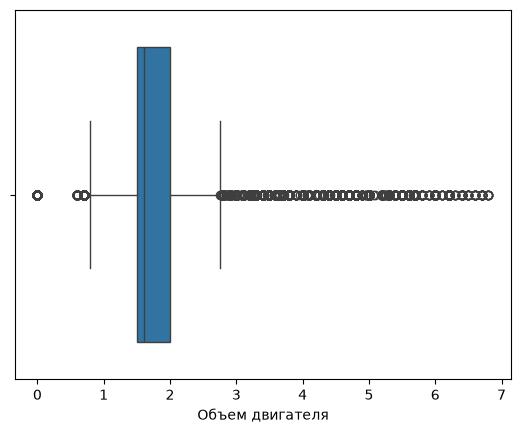

Распределение для столбца 'Мощность'


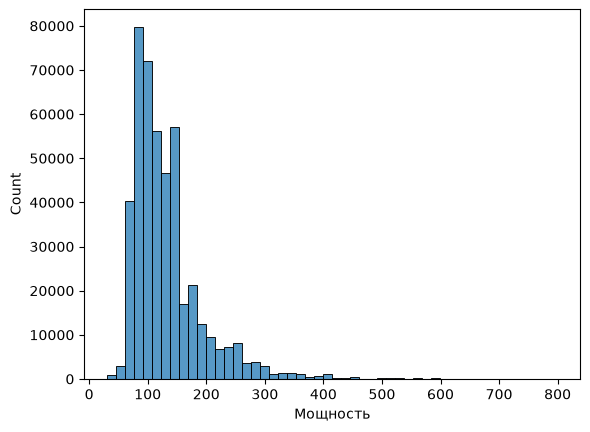

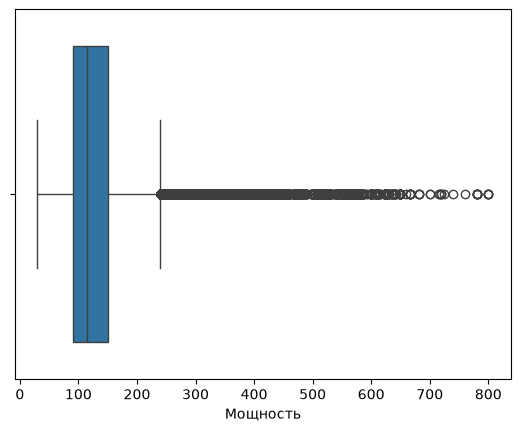

Распределение для столбца 'Пробег'


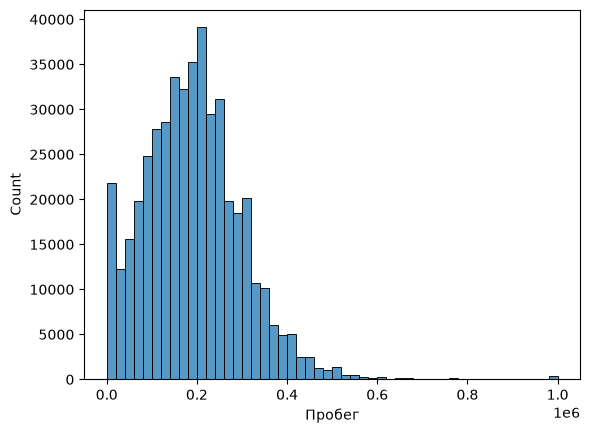

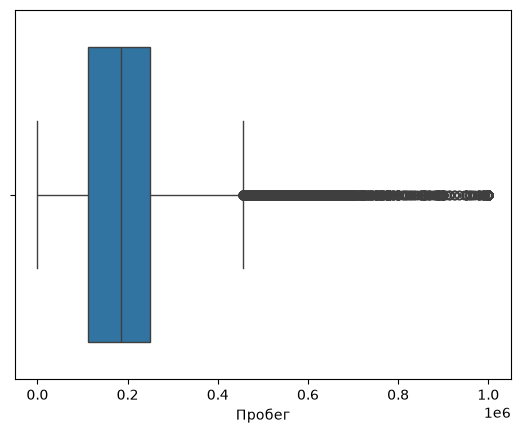

Распределение для столбца 'Поколение'


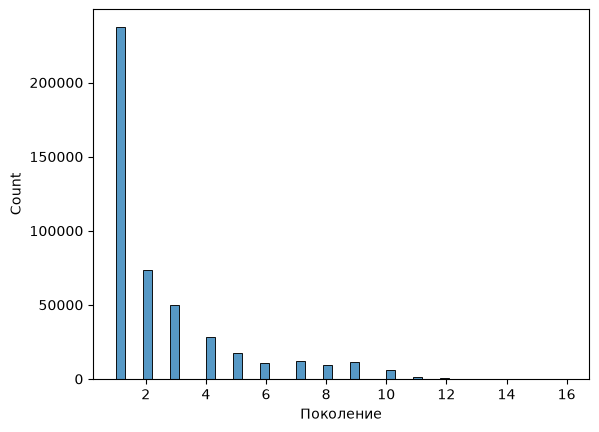

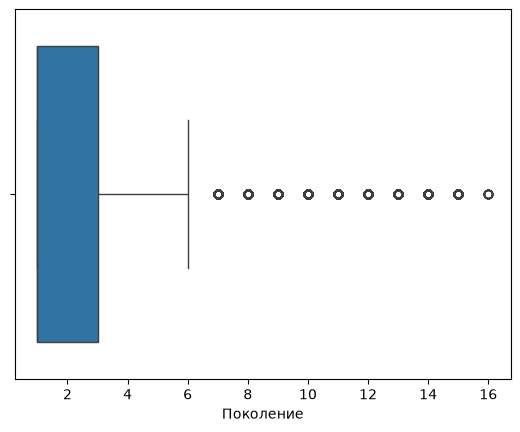

Распределение для столбца 'Рестайлинг'


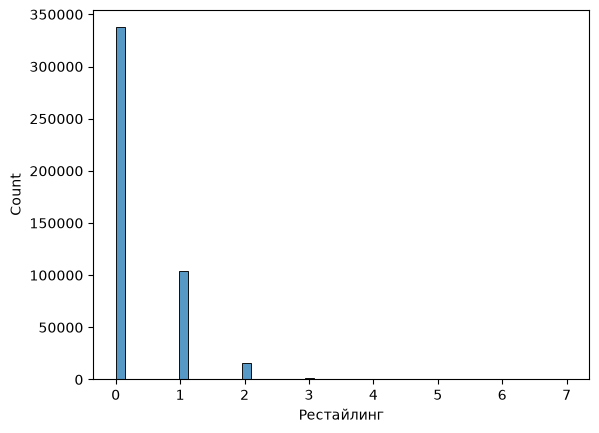

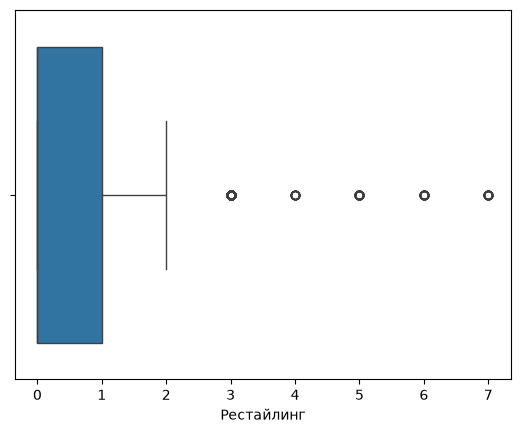

Распределение для столбца 'Владельцы'


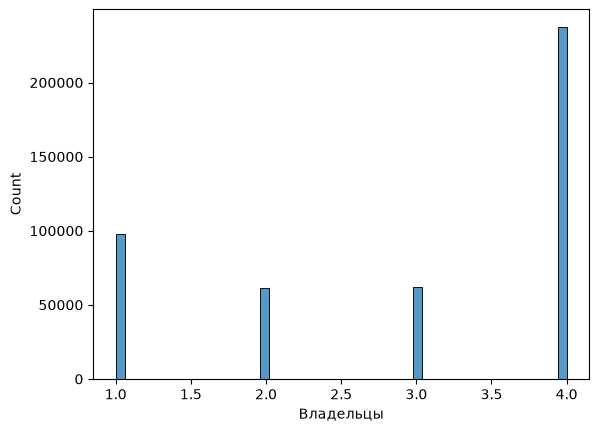

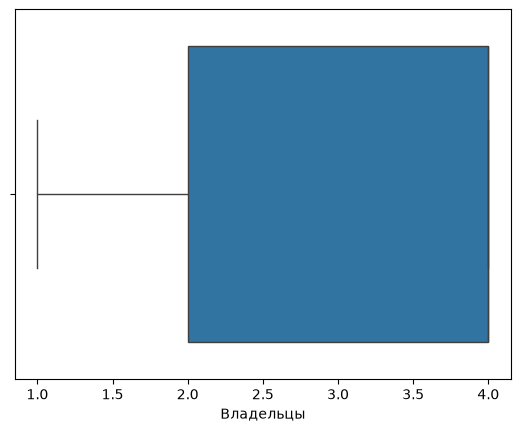

Распределение для столбца 'Есть особые отметки'


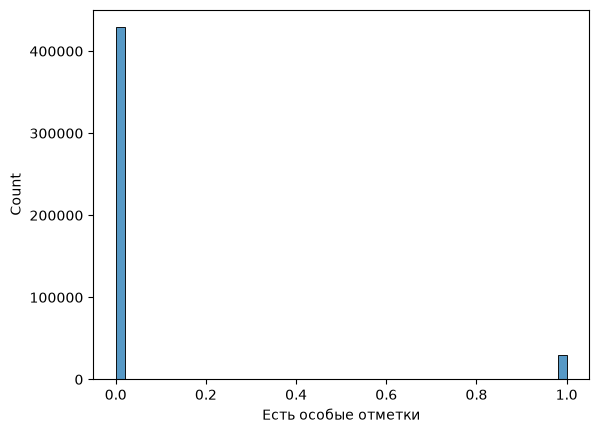

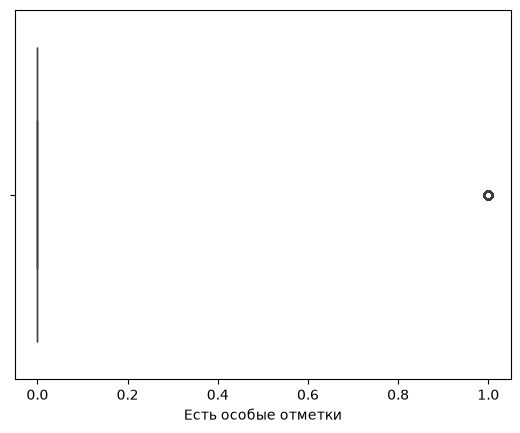

Распределение для столбца 'Цена'


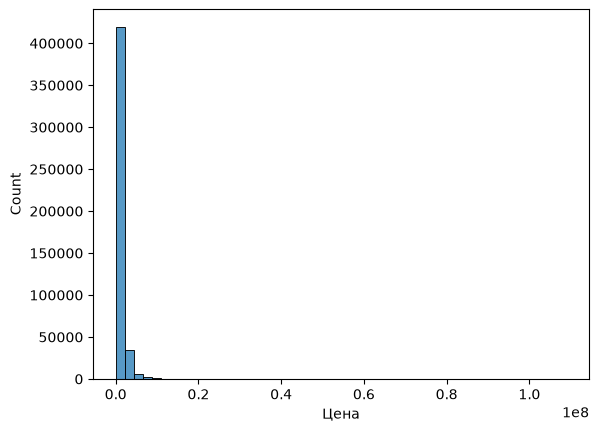

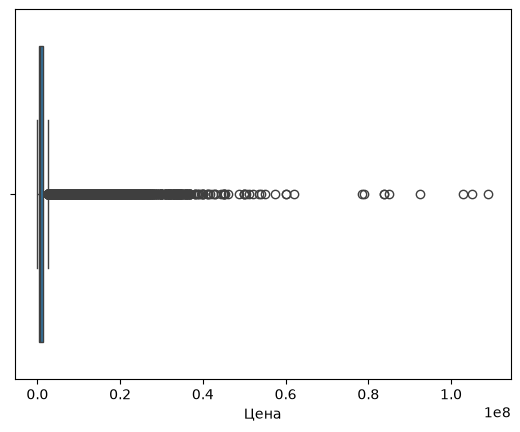

In [10]:
for col in num_cols:
    print(f"Распределение для столбца '{col}'")
    sns.histplot(data=df, x=col, bins=50)
    plt.show()
    sns.boxplot(data=df, x=col)
    plt.show()

Выводы по разделу 4.1

В ходе анализа распределений числовых признаков были сделаны следующие наблюдения:

1. **Целевая переменная (Цена), а также признаки "Пробег" и "Мощность"** имеют выраженную асимметрию с длинными правыми хвостами (несколько экстремально дорогих, мощных машин и машин с огромным пробегом). 
   * **Проблема:** Такой сильный разброс масштабов может негативно повлиять на сходимость моделей и устойчивость прогнозов (особенно для линейных алгоритмов).
   * **Решение:** На этапе Feature Engineering планируется применить логарифмическое преобразование для этих трех признаков, чтобы стабилизировать дисперсию и привести их распределения к более симметричному (близкому к нормальному) виду.

2. **Идеи для FE:**
    1. У нас есть выраженный "столбик" на значении 0 у признака "Пробег. Это значит, что машины полностью новые. На пятом этапе сможем создать новый бинарный признак - новая ли машина.
    2. Следуя этой же логике, сможем создать другой признак - электрическая ли машина.

4.2 Категориальные признаки

In [11]:
print(cat_cols)

['Название машины', 'Тип двигателя', 'Коробка передач', 'Привод', 'Руль', 'Цвет', 'Комплектация', 'Тип кузова', 'Марка', 'Город', 'Регион', 'Макро-регион']


Столбчатая диаграмма для Тип двигателя


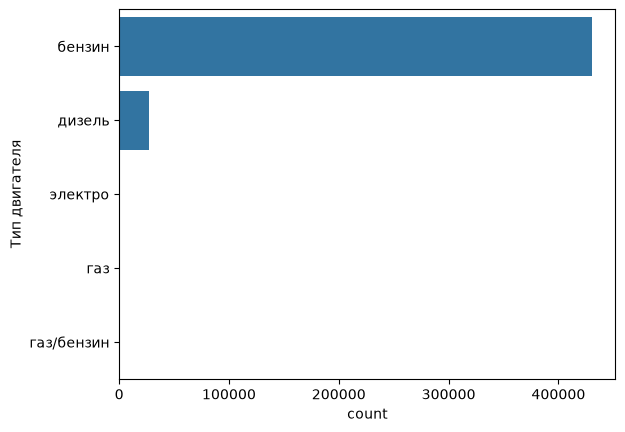

Столбчатая диаграмма для Коробка передач


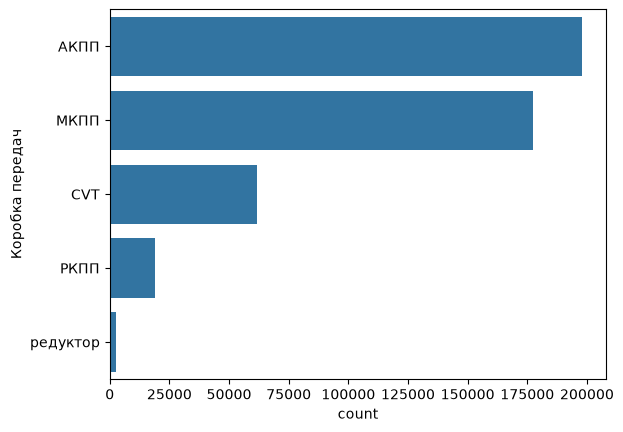

Столбчатая диаграмма для Привод


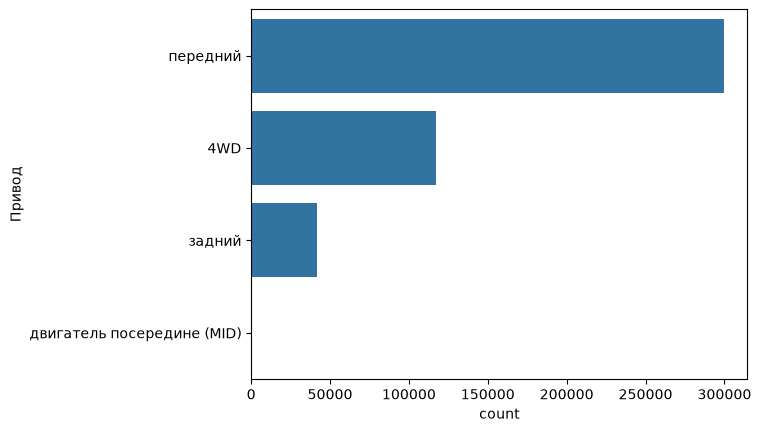

Столбчатая диаграмма для Руль


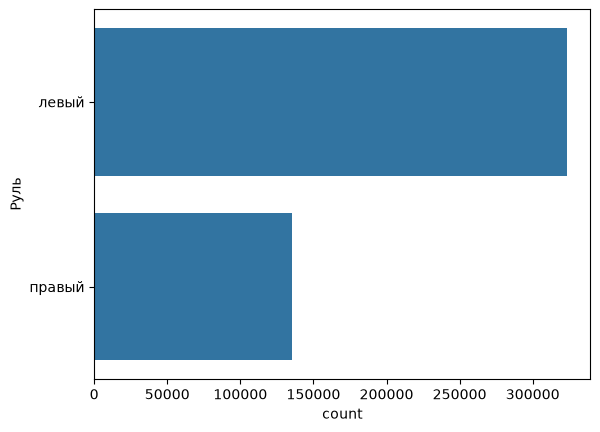

Столбчатая диаграмма для Цвет


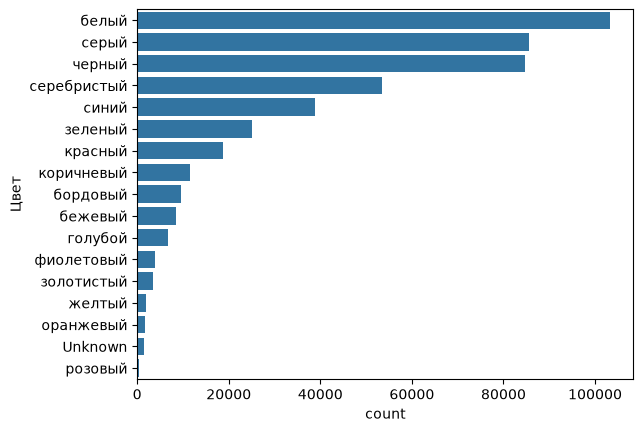

In [16]:
for col in cat_cols[1:6]:
    print(f'Столбчатая диаграмма для {col}')
    sns.countplot(data=df, y=col, order=df[col].value_counts().index)
    plt.show()

In [23]:
display(df['Город'].value_counts().tail(20))
display(df['Регион'].value_counts().tail(20))
display(df['Макро-регион'].value_counts().head(20))


Город
Хатассы              1
Гапцах               1
Татарская Каргала    1
Мюрего               1
Сапожок              1
Верхнее Казанище     1
Красногородск        1
Староюрьево          1
Хиславичи            1
Старокучергановка    1
Нижний Чир           1
Уразово              1
Синдор               1
Горагорский          1
Холм                 1
Султан-Янги-Юрт      1
Кысыл-Сыр            1
Кикуни               1
Тельмана             1
Колобово             1
Name: count, dtype: int64

Регион
Псковская область                  514
Кабардино-Балкарская Республика    508
Новгородская область               480
Республика Марий Эл                473
Республика Карелия                 467
Республика Коми                    439
Карачаево-Черкесская Республика    279
Республика Калмыкия                 67
Северо-Казахстанская область        11
Ненецкий автономный округ            8
Чукотский автономный округ           7
Западно-Казахстанская область        5
Павлодарская область                 4
Восточно-Казахстанская область       3
Карагандинская область               3
Гродненская область                  2
Гомельская область                   1
Астана                               1
Брестская область                    1
Мангистауская область                1
Name: count, dtype: int64

Макро-регион
СФО                124460
ДФО                 68780
ЮФО                 57412
УрФО                54704
ПФО                 34279
ЦФО                 26164
Новосибирск         25294
Москва              19025
СКФО                15229
Екатеринбург        13458
Санкт-Петербург      7887
СЗФО                 5940
Беларусь             2994
Казань               2819
Казахстан              28
Name: count, dtype: int64

Эти 3 признака сильно коррелируют. Разумнее всего будет оставить лишь Регион - он не такой детальный, как признак Город (в котором есть даже названия посёлков), но и содержит достаточно уникальных значений, в отличие от Макро-региона.

5. Двумерный анализ: признаки & таргет

5.1 Числовые признаки и таргет

Построим график Цена vs Пробег

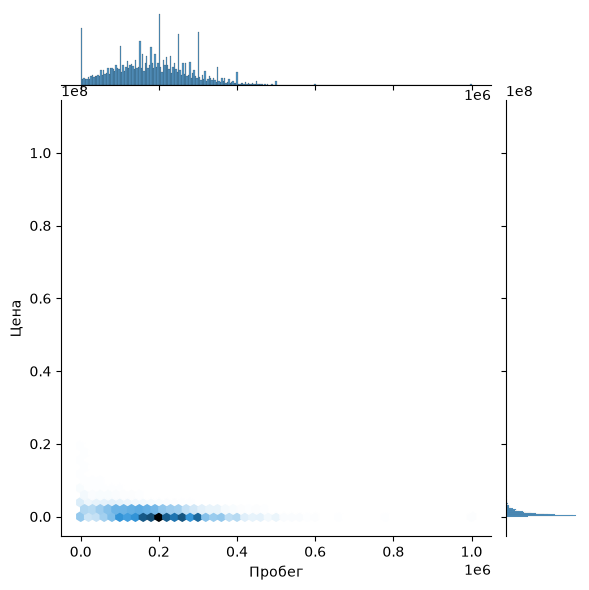

In [39]:
sns.jointplot(kind='hex', data=df, x=df['Пробег'], y=df['Цена'])

Попытка построить связь цены и пробега напрямую. Из-за экстремальных выбросов в ценах (до 100 млн руб.) и пробегах масштаб графика исказился, и 99% данных оказались сплющены внизу у левой оси. Взаимосвязь нечитаема

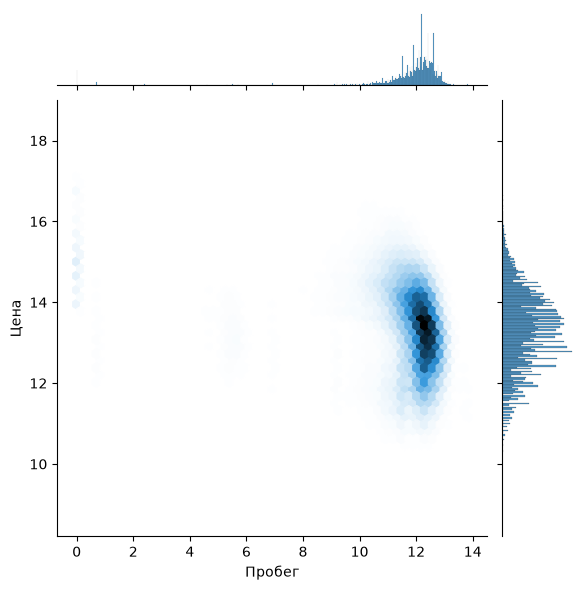

In [41]:
sns.jointplot(kind='hex', data=df, x=np.log1p(df['Пробег']), y=np.log1p(df['Цена']))

Тот же график после применения логарифмического преобразования log1p к обеим переменным. Масштаб нормализовался, экстремальные значения сгладились. Теперь четко виден отрицательный тренд: с увеличением пробега цена автомобиля закономерно снижается. Исключением являются бледные соты в районе нулевого пробега - это новые машины, и, что логично, они стоят дорого.

Построим график Цена vs Мощность

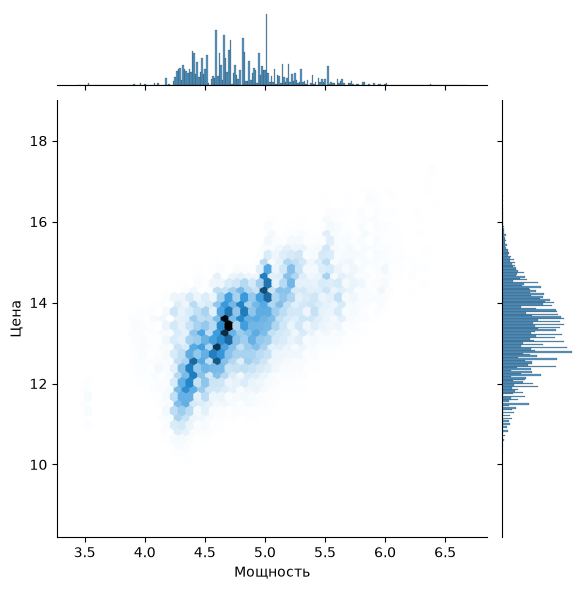

In [43]:
sns.jointplot(kind='hex', data=df, x=np.log1p(df['Мощность']), y=np.log1p(df['Цена']))

Можем заметить, что чем больше мощность - тем больше цена. Связь линейная. Линейность на лог-шкале указывает на то, что в исходных величинах зависимость носит экспоненциальный характер (каждые дополнительные лошадиные силы дают кратный прирост к цене). Наибольшая плотность объявлений (самый темный сектор) сосредоточена в диапазоне логарифма мощности 4.5–4.8 (что соответствует ~90–120 л.с. в реальных величинах) и логарифма цены 12.5–13.5 (около 270–730 тыс. рублей) - это ядро нашего масс-маркета.

Построим график Цена vs Год

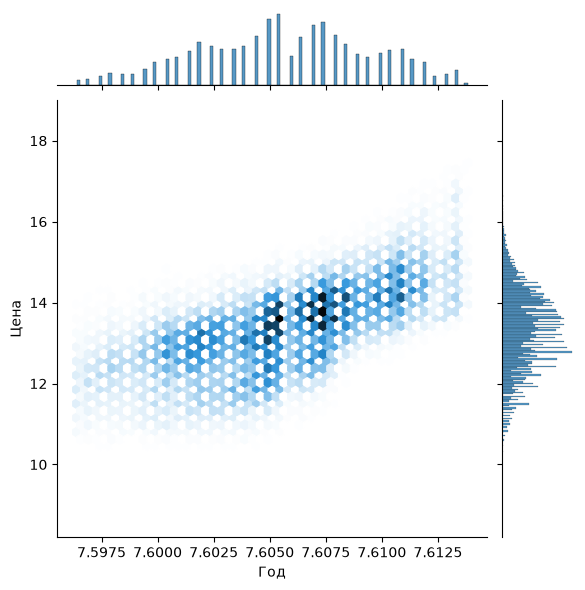

In [44]:
sns.jointplot(kind='hex', data=df, x=np.log1p(df['Год']), y=np.log1p(df['Цена']))

На графике зависимости цены от года выпуска виден четкий положительный тренд: чем новее автомобиль, тем выше его логарифмическая стоимость.